# SIMILIS Data-Centric — итоговый отчёт

Воспроизводимый сводный ноутбук по треку **1.2 SIMILIS — data-centric**. Здесь нет обучения и нет вычислений на GPU —
все цифры, графики и confusion matrices читаются из уже сохранённых артефактов pipeline.

Pipeline-скрипты:
`src/similis_baseline/data_centric_split.py`,
`data_centric_eda.py`,
`data_centric_sanity_check.py`,
`uncertainty_and_embeddings.py`,
`nearest_neighbors_viz.py`,
`review_table.py`,
`al_strategies.py`,
`al_loop.py`,
`al_compare.py`,
`scripts/dc_final_analysis.py`.

Подробное обоснование решений — в `REPORT_DATA_CENTRIC.md`. Подробный gap-чеклист — в `DATA_CENTRIC_CHECKLIST.md`.


## 1. Окружение, seed и data-centric папки

In [1]:
import json, sys, platform
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchvision
from IPython.display import Image as IPyImage, Markdown, display

ROOT = Path('.').resolve()
print('cwd          :', ROOT)
print('python       :', sys.version.split()[0])
print('platform     :', platform.platform())
print('torch        :', torch.__version__)
print('torchvision  :', torchvision.__version__)
print('cuda         :', torch.cuda.is_available())
print('mps          :', getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available())


cwd          : /Users/gipnotyin/Downloads/similis_baseline_project
python       : 3.13.0
platform     : macOS-26.1-arm64-arm-64bit-Mach-O
torch        : 2.11.0
torchvision  : 0.26.0
cuda         : False
mps          : True


In [2]:
for p in [
    'data/processed/data_centric',
    'artifacts/checkpoints/data_centric',
    'artifacts/reports/data_centric',
    'artifacts/review',
    'artifacts/embeddings',
    'artifacts/active_learning',
]:
    exists = Path(p).exists()
    print(f'  {p:42s} exists={exists}')


  data/processed/data_centric                exists=True
  artifacts/checkpoints/data_centric         exists=True
  artifacts/reports/data_centric             exists=True
  artifacts/review                           exists=True
  artifacts/embeddings                       exists=True
  artifacts/active_learning                  exists=True


## 2-3. Пулы и роли

4 пула с фиксированным seed:

| pool | роль | метки |
|---|---|---|
| `train_seed` | стартовый train для baseline-под-AL и retrain'ов после query | открыто |
| `val_gold` | чистая (label_is_uncertain=0) валидация для выбора стратегии | открыто |
| `test_gold` | финальная метрика, = baseline test_open для прямого сравнения | открыто |
| `pool_candidate` | пул на доразметку, метки скрыты (`__HIDDEN__`); правда в `pool_candidate_oracle.csv` | закрыто до query |


In [3]:
with open('artifacts/reports/data_centric/split_report.json', encoding='utf-8') as f:
    sr = json.load(f)
for k in ['seed','sizes','all_intersections_zero','covers_full_corpus']:
    if k in sr:
        print(f'  {k:35s} {sr[k]}')


  seed                                42
  sizes                               {'full_manifest': 1387, 'test_gold': 209, 'val_gold': 150, 'train_seed': 350, 'pool_candidate': 678, 'covered_total': 1387, 'uncovered_rows': 0}
  all_intersections_zero              True
  covers_full_corpus                  True


In [4]:
manifest = pd.read_csv('data/processed/data_centric/manifest_data_centric.csv')
print('manifest rows:', len(manifest))
print('pool counts :', manifest['pool'].value_counts().to_dict())
manifest[['code','image_file','pool','quality_flag','noise_score','label_is_uncertain']].head(10)


manifest rows: 1387
pool counts : {'pool_candidate': 678, 'train_seed': 350, 'test_gold': 209, 'val_gold': 150}


,code,image_file,pool,quality_flag,noise_score,label_is_uncertain
0,М102-2012-1-0494,data/raw/images/М102-2012-1-0494_orig.jpg,pool_candidate,hidden,NaN,1
1,М102-2012-1-0496,data/raw/images/М102-2012-1-0496_orig.jpg,train_seed,incomplete,0.1,0
2,М102-2012-1-0529,data/raw/images/М102-2012-1-0529_orig.jpg,test_gold,incomplete,0.1,0
3,М102-2012-1-0585,data/raw/images/М102-2012-1-0585_orig.jpg,pool_candidate,hidden,NaN,1
4,М102-2012-1-0603,data/raw/images/М102-2012-1-0603_orig.jpg,test_gold,uncertain,0.5,1
5,М102-2012-1-0611,data/raw/images/М102-2012-1-0611_orig.jpg,test_gold,incomplete,0.1,0
6,М102-2012-1-0691,data/raw/images/М102-2012-1-0691_orig.jpg,pool_candidate,hidden,NaN,0
7,М102-2012-1-0752,data/raw/images/М102-2012-1-0752_orig.jpg,train_seed,uncertain,0.4,1
8,М102-2012-1-0827,data/raw/images/М102-2012-1-0827_orig.jpg,test_gold,uncertain,0.5,1
9,М102-2012-1-0833,data/raw/images/М102-2012-1-0833_orig.jpg,train_seed,uncertain,0.5,1


## 4. EDA по пулам — структура, label noise, nuisance

In [5]:
with open('artifacts/reports/data_centric/pool_structure.json', encoding='utf-8') as f:
    ps = json.load(f)
rows = []
for pool, info in ps.items():
    rows.append({'pool': pool, **info})
pd.DataFrame(rows)


,pool,rows,unique_codes,unique_image_files,unique_group_keys,duplicated_image_files,repeated_group_keys,valid_image_rows,broken_image_rows
0,train_seed,350,350,350,350,0,0,350,0
1,val_gold,150,150,150,150,0,0,150,0
2,test_gold,209,209,209,209,0,0,209,0
3,pool_candidate,678,678,678,678,0,0,678,0


In [6]:
noise_dist = pd.read_csv('artifacts/reports/data_centric/noise_score_distribution.csv')
noise_dist


,pool,rows,mean,median,p75,p90,max,rows_score_ge_0_3,rows_score_ge_0_5
0,train_seed,350,0.079429,0.1,0.1,0.1,0.6,26,13
1,val_gold,150,0.056667,0.0,0.1,0.1,0.4,5,0
2,test_gold,209,0.073206,0.1,0.1,0.1,0.5,13,4


In [7]:
noise_top = pd.read_csv('artifacts/reports/data_centric/label_noise_candidates.csv').head(10)
noise_top[['code','description','type','material','noise_score','quality_flag','noise_reasons']]


,code,description,type,material,noise_score,quality_flag,noise_reasons
0,ВО-1л58-2017-0022,Плитки (напольной ?) (метлахской ?) серо-бежев...,прочее,керамика,0.6,uncertain,uncertain_text;incomplete_2
1,Т-12-Р2-3018,Предмета деревянного со сквозным отверстием (к...,крышка,прочее,0.6,uncertain,uncertain_text;incomplete_2
2,М102-2012-2-1095,Изразца(?) белоглиняного с белой поливой фр-т,изразец,керамика,0.5,uncertain,uncertain_text;incomplete_1
3,ВО-1л58-2017-0767,Изразец-перемычка белоглиняный со следами бело...,изразец,керамика,0.5,uncertain,uncertain_text;incomplete_1
4,ВО-1л58-2017-0077,Чайника/сахарницы (?) фарфорового с белой поли...,крышка,фарфор,0.5,uncertain,uncertain_text;incomplete_1
5,Нц-24-026,Тарелки (?) стеклянной края фр-т,тарелка,стекло,0.5,uncertain,uncertain_text;incomplete_1
6,Нц-35-151,Сосуда (тарелки?) фарфорового донной части фр-т,тарелка,фарфор,0.5,uncertain,uncertain_text;incomplete_1
7,КБ-2014-Р2-0643,Сосуда парфюмерного (?) прямоугольного прозрач...,крышка,стекло,0.5,uncertain,uncertain_text;incomplete_1
8,ВО-1л58-2017-1005,Изразца (карнизного пояса-каблучка углового?) ...,изразец,керамика,0.5,uncertain,uncertain_text;incomplete_1
9,КБ-2014-Р2-0755,Изразец (?) полуколонна красноглиняный с релье...,изразец,керамика,0.5,uncertain,uncertain_text;incomplete_1


In [8]:
for f in ['material','part','type','integrity']:
    p = Path(f'artifacts/reports/data_centric/nuisance_breakdown_{f}.csv')
    if p.exists():
        df = pd.read_csv(p)
        display(Markdown(f'### nuisance breakdown — {f}'))
        display(df.head(20))


### nuisance breakdown — material

,field,class,factor,value,count,share
0,material,керамика,layout_mode,single_object,515,0.7851
1,material,керамика,layout_mode,multi_view,131,0.1997
2,material,керамика,layout_mode,close_up,10,0.0152
3,material,керамика,bg_type,white_uniform,516,0.7866
4,material,керамика,bg_type,light_photo,139,0.2119
5,material,керамика,bg_type,dark_or_complex,1,0.0015
6,material,керамика,foreground_ratio_bin,ge_0.30,418,0.6372
7,material,керамика,foreground_ratio_bin,0.15_0.30,236,0.3598
8,material,керамика,foreground_ratio_bin,0.08_0.15,2,0.0030
9,material,керамика,has_scale_bar,0,656,1.0000


### nuisance breakdown — part

,field,class,factor,value,count,share
0,part,венчик,layout_mode,single_object,136,0.8500
1,part,венчик,layout_mode,multi_view,17,0.1062
2,part,венчик,layout_mode,close_up,7,0.0437
3,part,венчик,bg_type,white_uniform,114,0.7125
4,part,венчик,bg_type,light_photo,46,0.2875
5,part,венчик,foreground_ratio_bin,ge_0.30,80,0.5000
6,part,венчик,foreground_ratio_bin,0.15_0.30,77,0.4813
7,part,венчик,foreground_ratio_bin,0.08_0.15,3,0.0187
8,part,венчик,has_scale_bar,0,160,1.0000
9,part,венчик,has_overlay_text,0,148,0.9250


### nuisance breakdown — type

,field,class,factor,value,count,share
0,type,блюдце,layout_mode,single_object,155,0.7209
1,type,блюдце,layout_mode,multi_view,54,0.2512
2,type,блюдце,layout_mode,close_up,6,0.0279
3,type,блюдце,bg_type,white_uniform,147,0.6837
4,type,блюдце,bg_type,light_photo,56,0.2605
5,type,блюдце,bg_type,dark_or_complex,12,0.0558
6,type,блюдце,foreground_ratio_bin,ge_0.30,148,0.6884
7,type,блюдце,foreground_ratio_bin,0.15_0.30,66,0.3070
8,type,блюдце,foreground_ratio_bin,0.08_0.15,1,0.0047
9,type,блюдце,has_scale_bar,0,215,1.0000


### nuisance breakdown — integrity

,field,class,factor,value,count,share
0,integrity,фрагмент,layout_mode,single_object,978,0.7623
1,integrity,фрагмент,layout_mode,multi_view,268,0.2089
2,integrity,фрагмент,layout_mode,close_up,37,0.0288
3,integrity,фрагмент,bg_type,white_uniform,971,0.7568
4,integrity,фрагмент,bg_type,light_photo,285,0.2221
5,integrity,фрагмент,bg_type,dark_or_complex,27,0.0210
6,integrity,фрагмент,foreground_ratio_bin,ge_0.30,800,0.6235
7,integrity,фрагмент,foreground_ratio_bin,0.15_0.30,471,0.3671
8,integrity,фрагмент,foreground_ratio_bin,0.08_0.15,12,0.0094
9,integrity,фрагмент,has_scale_bar,0,1282,0.9992


## 5. Выбор полей и гипотезы

Primary: **`material`** (4 trainable классов, baseline test 0.84 → есть место для роста, реальный шум описаний).
Secondary: **`part`** (5 классов, baseline test 0.59, ~42% missing — есть запас на доразметку).

Гипотезы (зафиксированы ДО запуска AL):

- **H1.** uncertainty_least_confidence > random по `material_macro_f1` на val_gold при B=50
- **H2.** diversity_coreset даёт меньше дублирования query (выше попарная дистанция) и не теряет в качестве
- **H3.** ≥30% строк в review-таблице окажутся label_noise_suspect (а не genuine errors)


## 6. Quality flags и noise_score в manifest

К baseline-нормализации добавлены:
- `noise_score` ∈ [0, 1]
- `flag_uncertain`, `flag_incomplete`, `flag_conflict`, `flag_rare`
- `noise_reasons` (semicolon-separated)
- `quality_flag` ∈ `{clean, incomplete, rare, conflict, uncertain, hidden}` (приоритет: uncertain > conflict > rare > incomplete > clean)
- `pool_candidate` всегда `quality_flag=hidden` (анти-leakage, noise_score не вычисляется)


In [9]:
rows = []
for pool in ['train_seed','val_gold','test_gold','pool_candidate']:
    sub = manifest[manifest['pool']==pool]
    flags = sub['quality_flag'].value_counts().to_dict() if 'quality_flag' in sub.columns else {}
    rows.append({'pool': pool, 'rows': int(len(sub)), **flags})
pd.DataFrame(rows).fillna(0)


,pool,rows,clean,incomplete,uncertain,conflict,hidden
0,train_seed,350,165.0,162.0,22.0,1.0,0.0
1,val_gold,150,79.0,68.0,1.0,2.0,0.0
2,test_gold,209,100.0,97.0,12.0,0.0,0.0
3,pool_candidate,678,0.0,0.0,0.0,0.0,678.0


## 7. Sanity-check протокола (`all_checks_pass`)


In [10]:
with open('artifacts/reports/data_centric/data_centric_sanity_check.json', encoding='utf-8') as f:
    sc = json.load(f)
for k in [
    'all_checks_pass','all_intersections_zero','val_gold_clean_by_baseline_flag',
]:
    if k in sc: print(f'  {k:42s} {sc[k]}')
print('  pool_candidate masked all_hidden:', sc['pool_candidate_masked']['all_hidden'])
print('  pool_candidate target_mask all_zero:', sc['dataset_batch_checks']['pool_candidate_eval'].get('pool_candidate_target_mask_all_zero_first_n'))
print('  transform train stochastic    :', sc['transform_determinism']['train_is_stochastic'])
print('  transform eval deterministic  :', sc['transform_determinism']['eval_is_deterministic'])


  all_checks_pass                            True
  all_intersections_zero                     True
  val_gold_clean_by_baseline_flag            True
  pool_candidate masked all_hidden: True
  pool_candidate target_mask all_zero: True
  transform train stochastic    : True
  transform eval deterministic  : True


## 8-10. Архитектура, главная метрика и baseline_seed

Multi-task `convnext_tiny @384` (идентично baseline). Главная метрика —
`material_macro_f1` на `val_gold`.


In [11]:
with open('artifacts/reports/data_centric/baseline_seed_model_summary.json', encoding='utf-8') as f:
    ms = json.load(f)
ms


{'checkpoint_path': 'artifacts/checkpoints/data_centric/baseline_seed_best.pt',
 'backbone': 'convnext_tiny',
 'image_size': 384,
 'fields': ['type', 'part', 'integrity', 'material'],
 'epoch': 8,
 'best_metric': 0.6826644647765977,
 'total_params': 27834739,
 'backbone_params': 27820128,
 'heads_params': 14611,
 'train_csv': 'data/processed/data_centric/train_seed.csv',
 'val_csv': 'data/processed/data_centric/val_gold.csv',
 'test_csv': 'data/processed/data_centric/test_gold.csv',
 'primary_field': 'material'}

In [12]:
log = pd.read_csv('artifacts/reports/data_centric/train_log.csv')
log


,epoch,train_loss,val_loss,type_acc,type_macro_f1,part_acc,part_macro_f1,integrity_acc,integrity_macro_f1,material_acc,material_macro_f1,mean_macro_f1,backbone_trainable,backbone_lr,head_lr
0,1,0.890795,0.870651,0.575342,0.479131,0.493976,0.246930,0.873333,0.585455,0.664384,0.459275,0.442698,0,0.000000,0.000300
1,2,0.613231,0.764806,0.684932,0.627800,0.506024,0.415156,0.853333,0.615205,0.726027,0.513097,0.542815,0,0.000000,0.000289
2,3,0.560852,0.741511,0.739726,0.644834,0.542169,0.293054,0.853333,0.652778,0.780822,0.670754,0.565355,1,0.000030,0.000256
3,4,0.306909,0.471284,0.794521,0.771706,0.626506,0.561481,0.926667,0.741014,0.767123,0.647438,0.680410,1,0.000028,0.000208
4,5,0.143104,0.592998,0.773973,0.751855,0.638554,0.571523,0.926667,0.718382,0.801370,0.667918,0.677419,1,0.000023,0.000150
5,6,0.059590,0.597239,0.739726,0.721964,0.698795,0.561505,0.926667,0.718382,0.787671,0.661138,0.665747,1,0.000016,0.000093
6,7,0.029639,0.626627,0.780822,0.751864,0.650602,0.524799,0.926667,0.690953,0.801370,0.687855,0.663868,1,0.000008,0.000045
7,8,0.015128,0.625367,0.787671,0.753358,0.698795,0.617237,0.926667,0.657036,0.815068,0.703027,0.682664,1,0.000003,0.000012
8,9,0.012293,0.613124,0.773973,0.746648,0.674699,0.605446,0.926667,0.657036,0.794521,0.683880,0.673253,1,0.000001,0.000001


### loss_curve.png

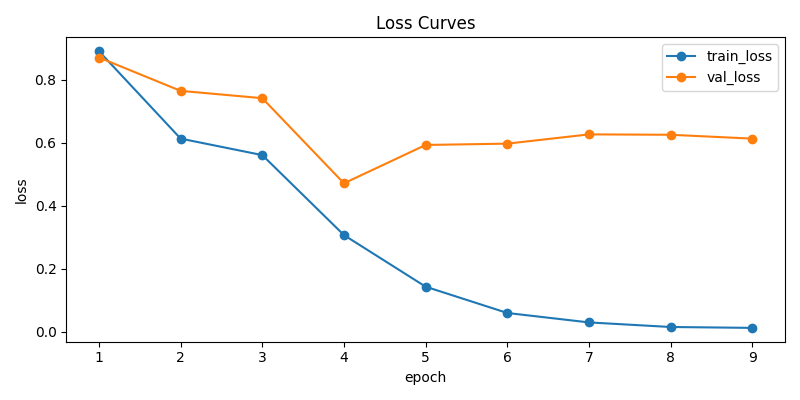

### macro_f1_curve.png

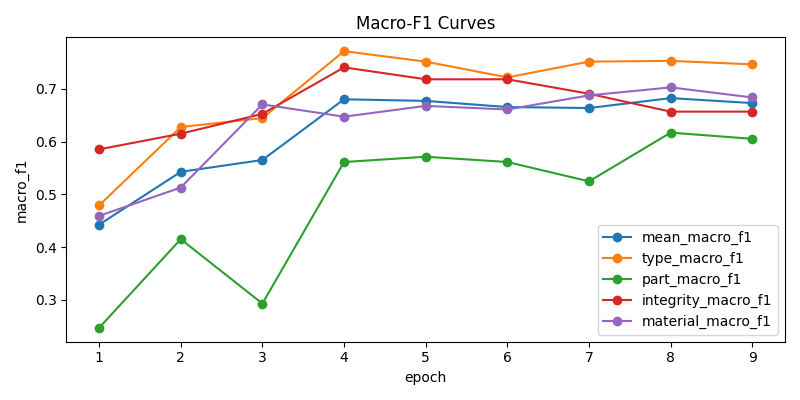

### lr_curve.png

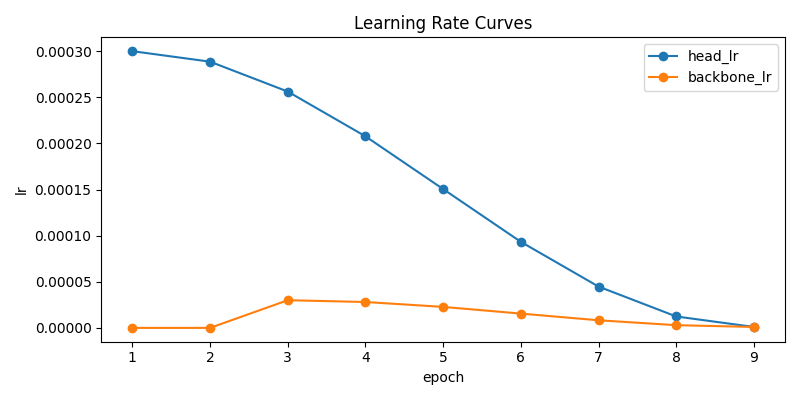

In [13]:
for fname in ['loss_curve.png','macro_f1_curve.png','lr_curve.png']:
    p = Path(f'artifacts/reports/data_centric/baseline_seed_train_log_report/{fname}')
    if p.exists():
        display(Markdown(f'### {fname}'))
        display(IPyImage(filename=str(p)))


In [14]:
with open('artifacts/reports/data_centric/baseline_seed_val_detailed/metrics.json', encoding='utf-8') as f:
    bv = json.load(f)
with open('artifacts/reports/data_centric/baseline_seed_test_detailed/metrics.json', encoding='utf-8') as f:
    bt = json.load(f)
display(Markdown('### baseline_seed — val_gold'))
display(bv)
display(Markdown('### baseline_seed — test_gold'))
display(bt)


### baseline_seed — val_gold

{'split': 'val',
 'rows': 150,
 'val_loss': 0.6253667518496513,
 'type_acc': 0.7876712328767124,
 'type_macro_f1': 0.7533576906619268,
 'part_acc': 0.6987951807228916,
 'part_macro_f1': 0.6172374429223744,
 'integrity_acc': 0.9266666666666666,
 'integrity_macro_f1': 0.6570359592600291,
 'material_acc': 0.815068493150685,
 'material_macro_f1': 0.7030267662620604,
 'mean_macro_f1': 0.6826644647765977}

### baseline_seed — test_gold

{'split': 'test',
 'rows': 209,
 'val_loss': 0.5028004510843728,
 'type_acc': 0.7621359223300971,
 'type_macro_f1': 0.7018707363809202,
 'part_acc': 0.6238532110091743,
 'part_macro_f1': 0.5083333333333333,
 'integrity_acc': 0.9234449760765551,
 'integrity_macro_f1': 0.6463620981387479,
 'material_acc': 0.8019323671497585,
 'material_macro_f1': 0.5817770757204566,
 'mean_macro_f1': 0.6095858108933645}

### baseline_seed val_gold — confusion `material`

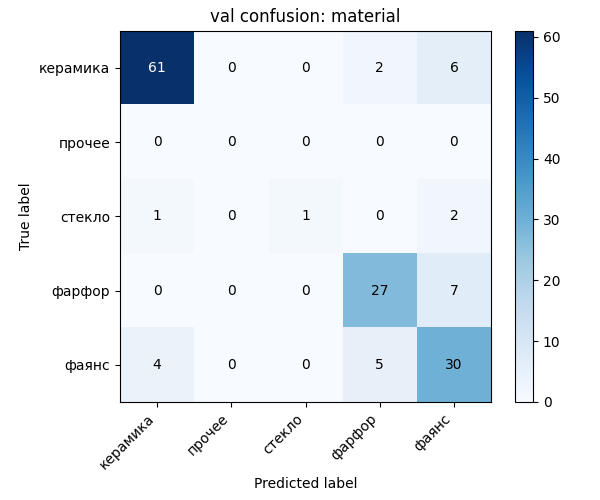

In [15]:
p = Path('artifacts/reports/data_centric/baseline_seed_val_detailed/confusion_material.png')
if p.exists():
    display(Markdown('### baseline_seed val_gold — confusion `material`'))
    display(IPyImage(filename=str(p)))


## 12. Сигналы неопределённости

3 сигнала на каждое поле: `max_prob` (1 - max softmax), `entropy`, `margin`.
Spearman 0.99+ между ними на всех пулах — взаимозаменяемые. Для AL #16 берём `least_confidence`.


In [16]:
with open('artifacts/embeddings/embeddings_summary.json', encoding='utf-8') as f:
    es = json.load(f)
rows = []
for pool, info in es['pools'].items():
    rows.append({
        'pool': pool,
        'rows': info['rows'],
        'emb_shape': info['embeddings_shape'],
        'max_prob_p50': info.get('material_max_prob_p50'),
        'max_prob_p90': info.get('material_max_prob_p90'),
        'entropy_p50': info.get('material_entropy_p50'),
        'entropy_p90': info.get('material_entropy_p90'),
        **info['spearman_correlations_primary_field'],
    })
pd.DataFrame(rows)


,pool,rows,emb_shape,max_prob_p50,max_prob_p90,entropy_p50,entropy_p90,max_prob_vs_entropy,max_prob_vs_neg_margin,entropy_vs_neg_margin
0,train_seed,350,"[350, 768]",0.013680,0.067723,0.080305,0.296086,0.998663,0.997752,0.993728
1,val_gold,150,"[150, 768]",0.044454,0.378681,0.200066,0.833073,0.994510,0.997792,0.987498
2,test_gold,209,"[209, 768]",0.047410,0.400073,0.218780,0.748647,0.993767,0.998617,0.988523
3,pool_candidate,678,"[678, 768]",0.037792,0.360002,0.177854,0.760453,0.993941,0.998779,0.988884


## 13. Эмбеддинги + nearest neighbors

768-d backbone-features, для топ-5 неуверенных pool_candidate показаны 3 ближайших соседа в train_seed.


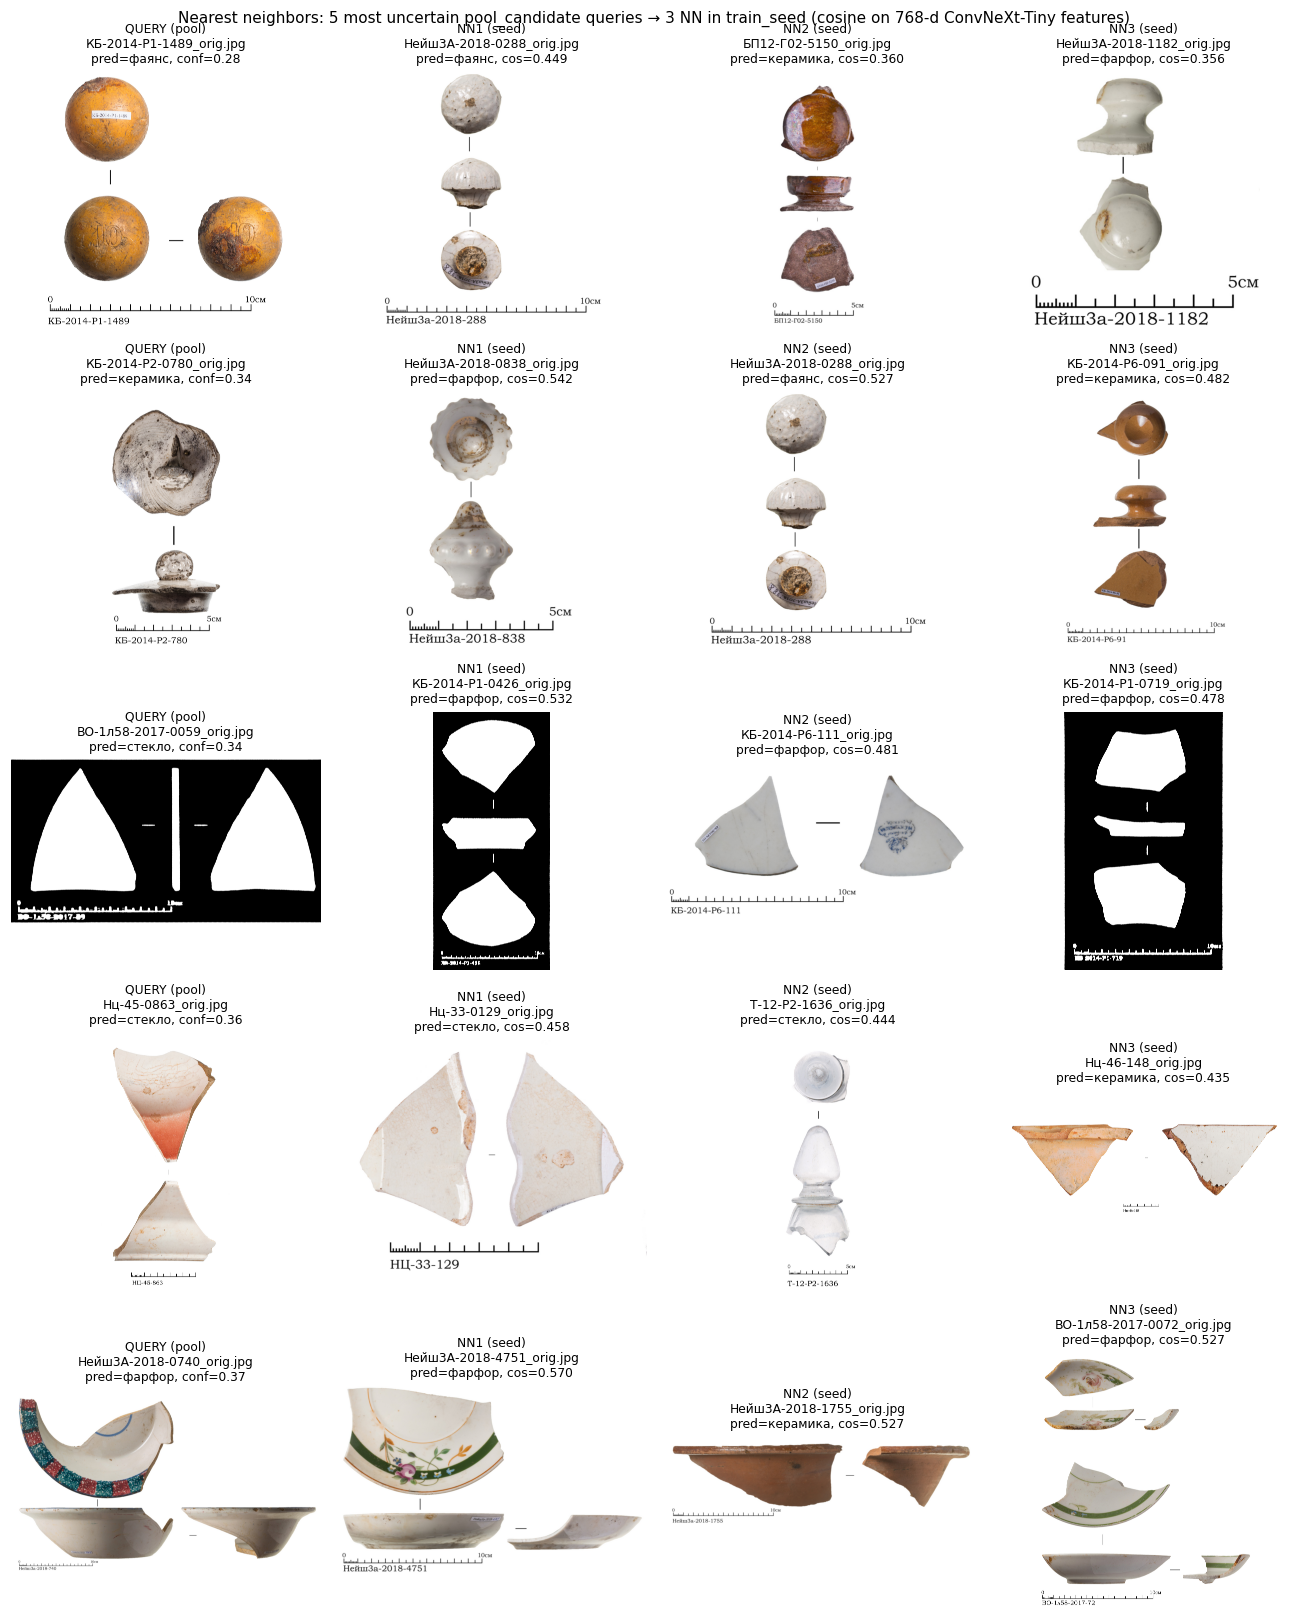

In [17]:
p = Path('artifacts/embeddings/nearest_neighbors/nearest_neighbors.png')
if p.exists():
    display(IPyImage(filename=str(p)))


In [18]:
nn = pd.read_csv('artifacts/embeddings/nearest_neighbors/nearest_neighbors.csv')
nn


,query_image,query_pred_field,query_pred,query_conf,neighbor_rank,neighbor_image,neighbor_pred,cosine_similarity
0,data/raw/images/КБ-2014-Р1-1489_orig.jpg,material,фаянс,0.282069,1,data/raw/images/Нейш3А-2018-0288_orig.jpg,фаянс,0.449139
1,data/raw/images/КБ-2014-Р1-1489_orig.jpg,material,фаянс,0.282069,2,data/raw/images/БП12-Г02-5150_orig.jpg,керамика,0.360088
2,data/raw/images/КБ-2014-Р1-1489_orig.jpg,material,фаянс,0.282069,3,data/raw/images/Нейш3А-2018-1182_orig.jpg,фарфор,0.356265
3,data/raw/images/КБ-2014-Р2-0780_orig.jpg,material,керамика,0.337052,1,data/raw/images/Нейш3А-2018-0838_orig.jpg,фарфор,0.542365
4,data/raw/images/КБ-2014-Р2-0780_orig.jpg,material,керамика,0.337052,2,data/raw/images/Нейш3А-2018-0288_orig.jpg,фаянс,0.526644
5,data/raw/images/КБ-2014-Р2-0780_orig.jpg,material,керамика,0.337052,3,data/raw/images/КБ-2014-Р6-091_orig.jpg,керамика,0.481869
6,data/raw/images/ВО-1л58-2017-0059_orig.jpg,material,стекло,0.338678,1,data/raw/images/КБ-2014-Р1-0426_orig.jpg,фарфор,0.532353
7,data/raw/images/ВО-1л58-2017-0059_orig.jpg,material,стекло,0.338678,2,data/raw/images/КБ-2014-Р6-111_orig.jpg,фарфор,0.480917
8,data/raw/images/ВО-1л58-2017-0059_orig.jpg,material,стекло,0.338678,3,data/raw/images/КБ-2014-Р1-0719_orig.jpg,фарфор,0.477812
9,data/raw/images/Нц-45-0863_orig.jpg,material,стекло,0.363519,1,data/raw/images/Нц-33-0129_orig.jpg,стекло,0.457790


## 14. Review-таблица (топ-40 подозрительных)

Ranking = 0.5·disagreement + 0.4·uncertainty + 0.3·noise_score + 0.2·embedding_outlier.
`reason_flag` ∈ `{label_noise_suspect, visual_nuisance, genuinely_hard}`.


In [19]:
rev = pd.read_csv('artifacts/review/review_table.csv')
print('review rows:', len(rev))
print('reason_flag distribution:', rev['reason_flag'].value_counts().to_dict())
print('disagreement count    :', int(rev['disagreement'].sum()))
rev[['pool','code','norm_label','pred_label','confidence','uncertainty_score','noise_score','combined_score','reason_flag','quality_flag']].head(10)


review rows: 40
reason_flag distribution: {'genuinely_hard': 32, 'label_noise_suspect': 4, 'visual_nuisance': 4}
disagreement count    : 40


,pool,code,norm_label,pred_label,confidence,uncertainty_score,noise_score,combined_score,reason_flag,quality_flag
0,val_gold,КБ-2014-Р2-0332,керамика,фарфор,0.3277,0.6723,0.1,0.9444,genuinely_hard,incomplete
1,test_gold,Нев11-под-001,керамика,фаянс,0.3978,0.6022,0.2,0.9399,genuinely_hard,incomplete
2,test_gold,Нейш3А-2018-1476,стекло,фарфор,0.4896,0.5104,0.4,0.9379,label_noise_suspect,uncertain
3,test_gold,М102-2012-1-0827,фаянс,фарфор,0.5242,0.4758,0.5,0.9242,label_noise_suspect,uncertain
4,test_gold,Нейш3А-2018-0741,фаянс,фарфор,0.3437,0.6563,0.0,0.8769,genuinely_hard,clean
5,train_seed,Нц-45-1296,фаянс,фарфор,0.5877,0.4123,0.1,0.8515,genuinely_hard,incomplete
6,val_gold,Нейш3А-2018-3692,стекло,керамика,0.5764,0.4236,0.2,0.8446,genuinely_hard,incomplete
7,val_gold,Нейш3А-2018-0254,фаянс,керамика,0.4223,0.5777,0.0,0.8346,genuinely_hard,clean
8,test_gold,М102-2012-2-1279,стекло,фарфор,0.4789,0.5211,0.1,0.8335,genuinely_hard,incomplete
9,test_gold,Нейш3А-2018-4499,стекло,фаянс,0.5262,0.4738,0.1,0.8228,genuinely_hard,incomplete


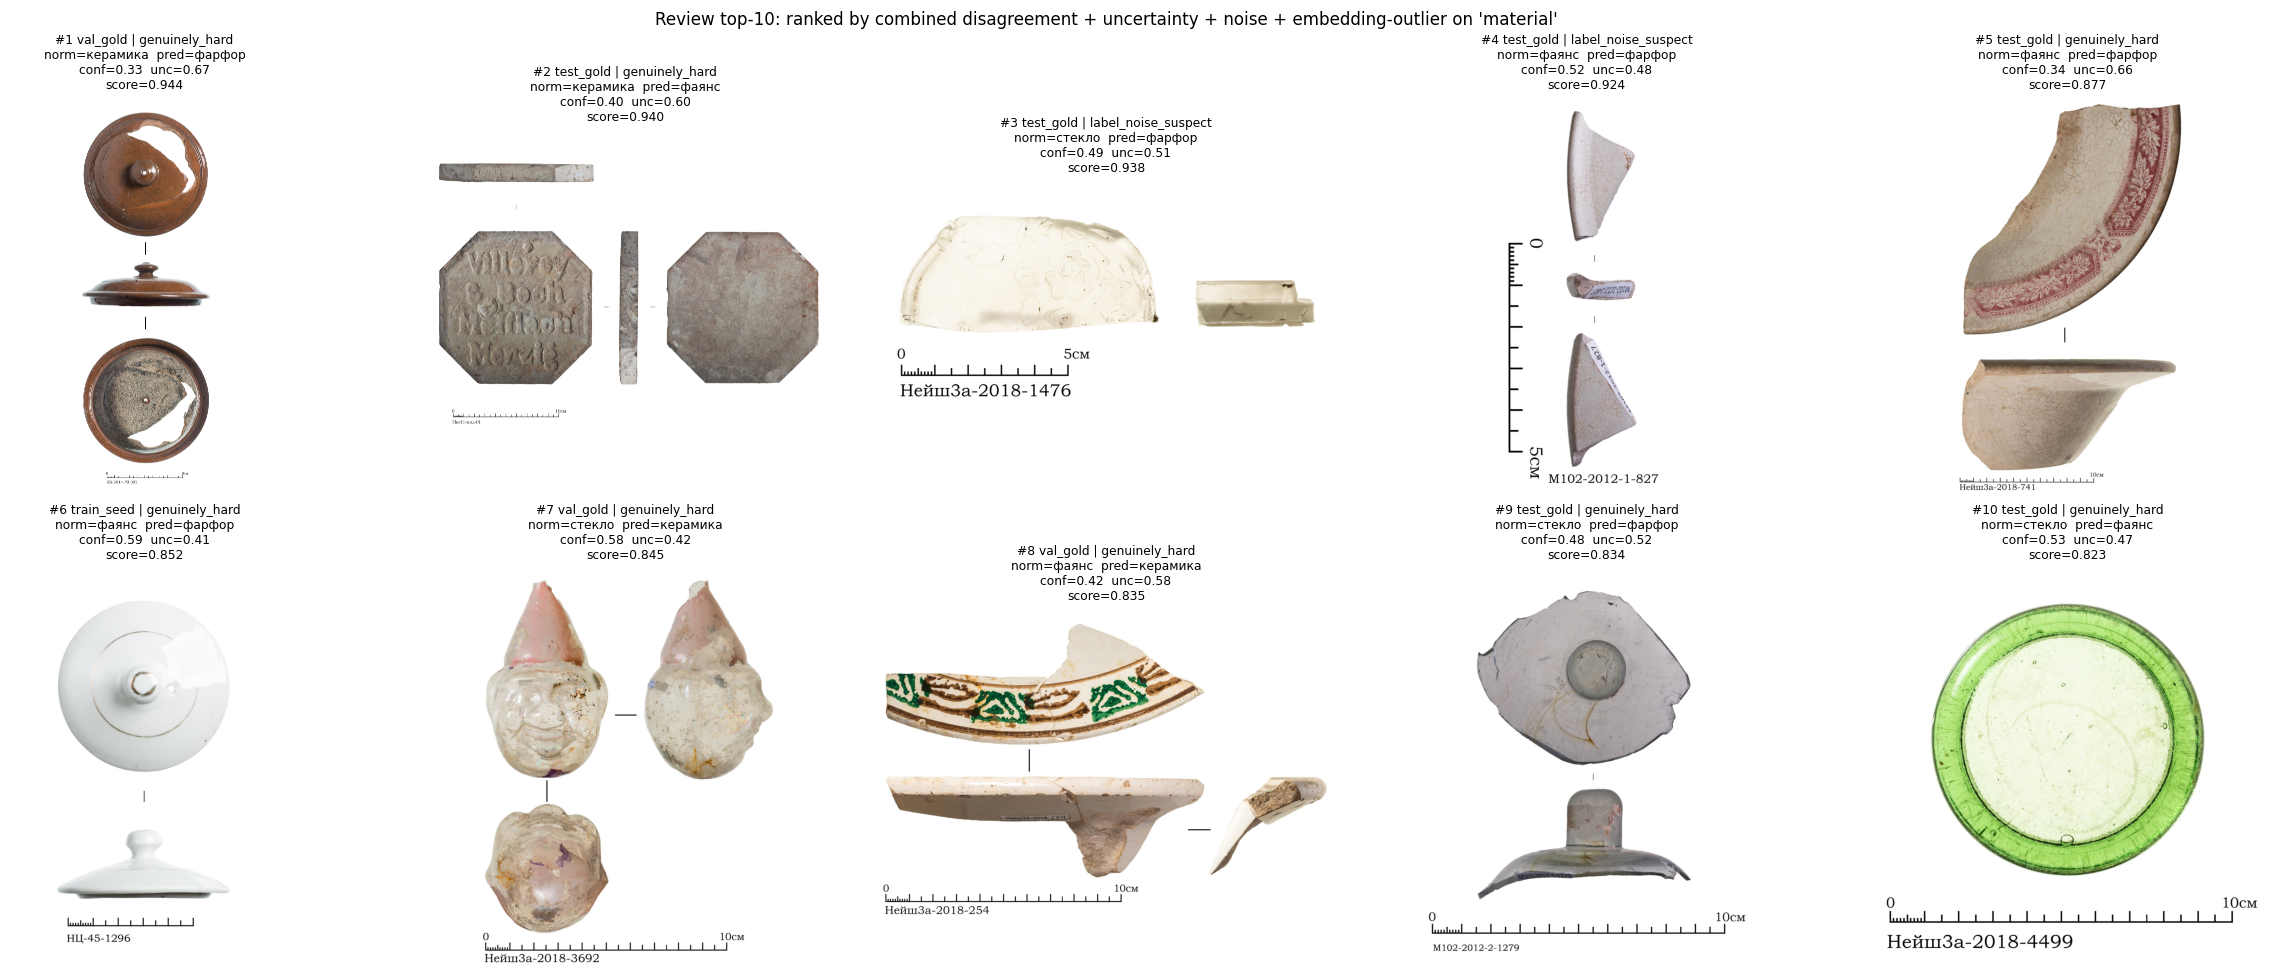

In [20]:
p = Path('artifacts/review/review_top10_grid.png')
if p.exists():
    display(IPyImage(filename=str(p)))


## 15-17. Стратегии query — отбор query без retrain

4 стратегии: random (control), least_confidence, coreset (k-center на эмбеддингах), hybrid (top-3B uncertain → coreset to B).
8 query-CSVs: 4 стратегии × 2 бюджета.


In [21]:
redund = pd.read_csv('artifacts/active_learning/comparison/strategy_redundancy.csv')
display(Markdown('### Avg pairwise cosine distance among queried (H2)'))
display(redund)


### Avg pairwise cosine distance among queried (H2)

,strategy,budget,avg_pairwise_cosine_distance
0,random,50,0.734072
1,least_confidence,50,0.738677
2,coreset,50,0.795060
3,hybrid,50,0.783356
4,random,100,0.764294
5,least_confidence,100,0.735519
6,coreset,100,0.774409
7,hybrid,100,0.769649


In [22]:
nuis = pd.read_csv('artifacts/active_learning/comparison/strategy_nuisance.csv')
display(Markdown('### Nuisance shares among queried'))
display(nuis)


### Nuisance shares among queried

,strategy,budget,close_up_share,multi_view_share,small_foreground_share,has_overlay_text_share,has_scale_bar_share,dark_or_complex_bg_share
0,random,50,0.02,0.22,0.00,0.08,0.0,0.00
1,least_confidence,50,0.08,0.12,0.00,0.10,0.0,0.02
2,coreset,50,0.02,0.22,0.02,0.16,0.0,0.04
3,hybrid,50,0.02,0.16,0.00,0.16,0.0,0.04
4,random,100,0.01,0.21,0.01,0.13,0.0,0.03
5,least_confidence,100,0.06,0.18,0.00,0.10,0.0,0.03
6,coreset,100,0.03,0.21,0.02,0.16,0.0,0.03
7,hybrid,100,0.02,0.20,0.01,0.18,0.0,0.03


In [23]:
for B in [50, 100]:
    p = Path(f'artifacts/active_learning/comparison/strategy_overlap_B{B}.csv')
    if p.exists():
        display(Markdown(f'### strategy overlap @ B={B} (image_files in common)'))
        display(pd.read_csv(p))


### strategy overlap @ B=50 (image_files in common)

,strategy,random,least_confidence,coreset,hybrid
0,random,50,5,5,4
1,least_confidence,5,50,11,20
2,coreset,5,11,50,26
3,hybrid,4,20,26,50


### strategy overlap @ B=100 (image_files in common)

,strategy,random,least_confidence,coreset,hybrid
0,random,100,15,11,15
1,least_confidence,15,100,34,41
2,coreset,11,34,100,80
3,hybrid,15,41,80,100


In [24]:
with open('artifacts/active_learning/comparison/all_strategies_summary.json', encoding='utf-8') as f:
    asum = json.load(f)
rows = []
for s in asum['summaries']:
    cdist = s.get(f"{s['primary_field']}_oracle_class_distribution", {})
    rows.append({
        'strategy': s['strategy'],
        'budget': s['budget'],
        **cdist,
    })
display(Markdown('### Class distribution in queried (after oracle reveal) on `material`'))
pd.DataFrame(rows).fillna(0).astype({'budget': int})


### Class distribution in queried (after oracle reveal) on `material`

,strategy,budget,керамика,фаянс,фарфор,стекло
0,random,50,19,18,9,2
1,least_confidence,50,5,32,9,1
2,coreset,50,11,22,7,5
3,hybrid,50,7,26,8,4
4,random,100,40,28,28,1
5,least_confidence,100,14,58,19,4
6,coreset,100,21,50,14,5
7,hybrid,100,18,47,19,6


## 18-19. AL симуляция и сравнение

3 стратегии × 2 бюджета = 6 retrain'ов. Recipe идентичен baseline_seed.


In [25]:
results = pd.read_csv('artifacts/active_learning/comparison/results.csv')
results


,strategy,budget,val_material_macro_f1,val_mean_macro_f1,test_material_macro_f1,test_mean_macro_f1,delta_val_material_vs_baseline,delta_val_mean_vs_baseline,delta_val_material_vs_random_same_budget,avg_pairwise_cosine_distance,close_up_share,small_foreground_share,has_overlay_text_share,notes
0,baseline_seed,0,0.703027,0.682664,0.581777,0.609586,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,B=0 reference (train_seed only)
1,coreset,50,0.787627,0.713909,0.643365,0.645474,0.084600,0.031245,0.094361,0.795060,0.02,0.02,0.16,NaN
2,hybrid,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.783356,0.02,0.00,0.16,NaN
3,least_confidence,50,0.685930,0.696715,0.706703,0.673404,-0.017097,0.014050,-0.007336,0.738677,0.08,0.00,0.10,NaN
4,random,50,0.693266,0.698050,0.654571,0.642199,-0.009761,0.015386,NaN,0.734072,0.02,0.00,0.08,NaN
5,coreset,100,0.699849,0.697369,0.706820,0.644798,-0.003177,0.014704,-0.040975,0.774409,0.03,0.02,0.16,NaN
6,hybrid,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.769649,0.02,0.01,0.18,NaN
7,least_confidence,100,0.681887,0.727628,0.733083,0.657809,-0.021139,0.044963,-0.058938,0.735519,0.06,0.00,0.10,NaN
8,random,100,0.740825,0.723353,0.639289,0.639924,0.037798,0.040689,NaN,0.764294,0.01,0.01,0.13,NaN


### val_material_macro_f1 vs budget (PRIMARY)

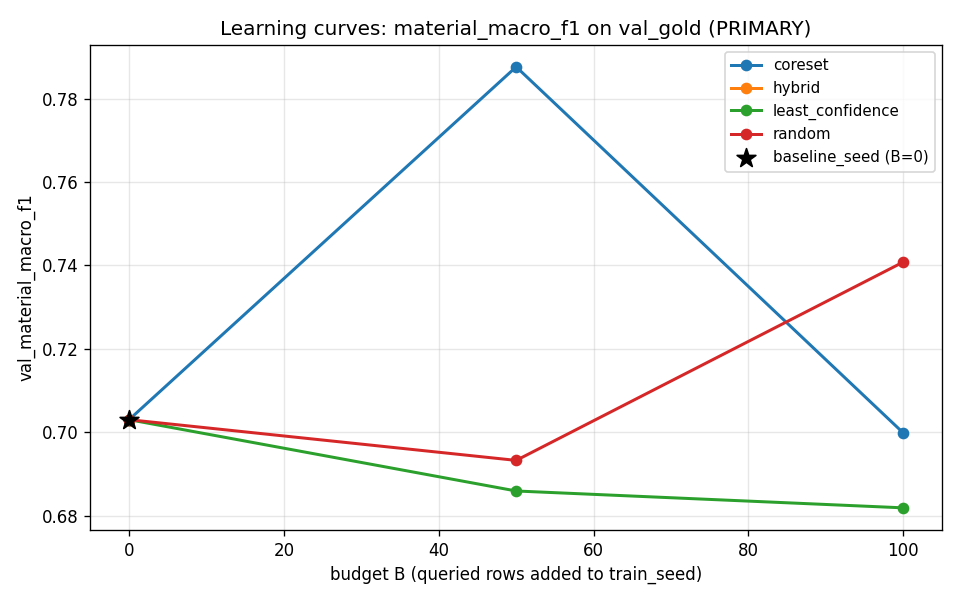

### val_mean_macro_f1 vs budget (4 fields)

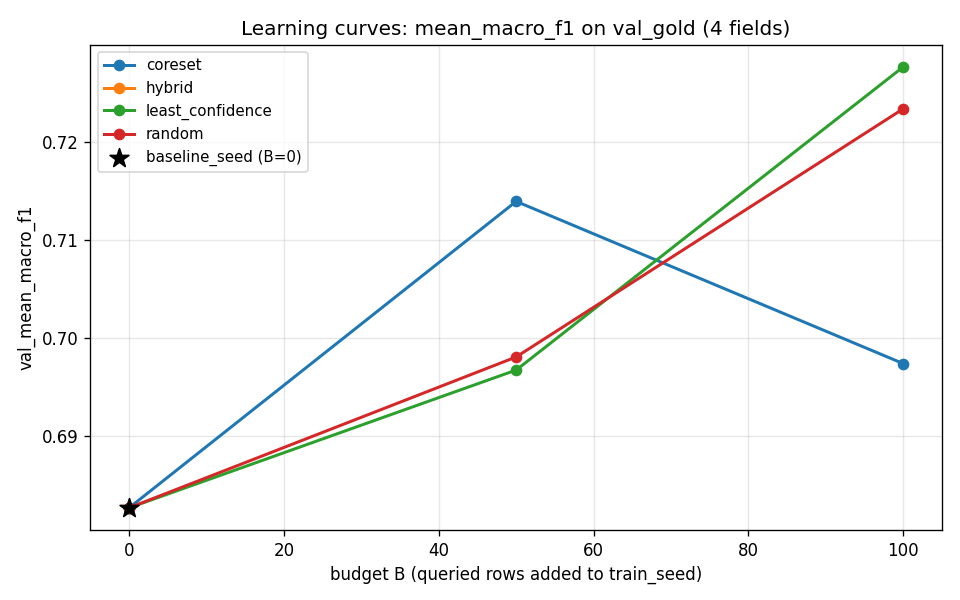

### test_material_macro_f1 vs budget (final eval)

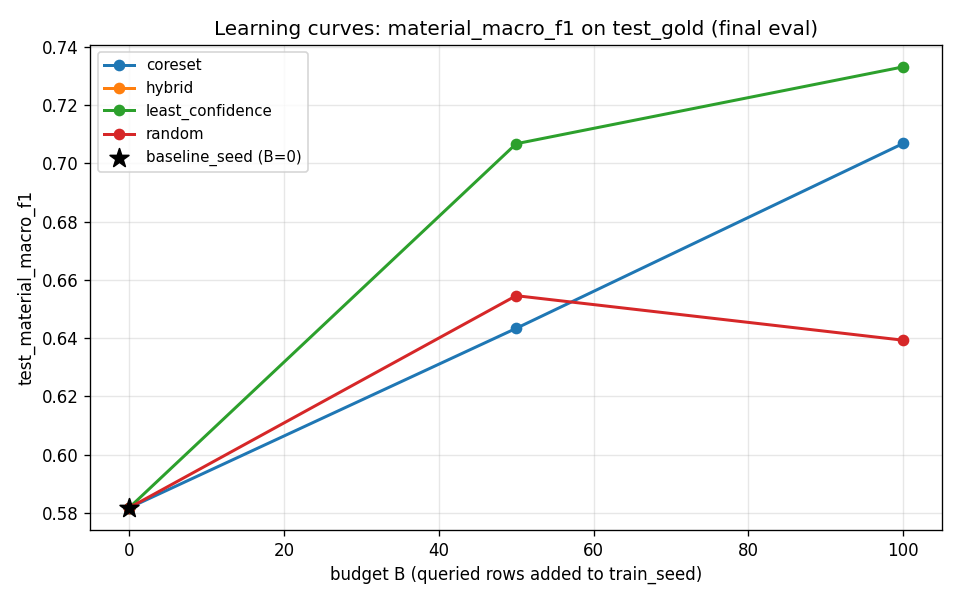

In [26]:
for fname, title in [
    ('learning_curves.png', 'val_material_macro_f1 vs budget (PRIMARY)'),
    ('learning_curves_mean.png', 'val_mean_macro_f1 vs budget (4 fields)'),
    ('learning_curves_test.png', 'test_material_macro_f1 vs budget (final eval)'),
]:
    p = Path(f'artifacts/active_learning/comparison/{fname}')
    if p.exists():
        display(Markdown(f'### {title}'))
        display(IPyImage(filename=str(p)))


In [27]:
notes = Path('artifacts/active_learning/comparison/notes.md').read_text(encoding='utf-8')
display(Markdown(notes))


# AL strategy comparison — auto notes
Primary metric: `material_macro_f1` on val_gold.
Reference (B=0, train_seed only): val=0.7030, test=0.5818

## Budget B=50
- **coreset** val_material=0.7876 (Δvs_seed=+0.0846, Δvs_random=+0.0944) test_material=0.6434 redund=0.795
- **random** val_material=0.6933 (Δvs_seed=-0.0098, Δvs_random=+nan) test_material=0.6546 redund=0.734
- **least_confidence** val_material=0.6859 (Δvs_seed=-0.0171, Δvs_random=-0.0073) test_material=0.7067 redund=0.739
- **hybrid** val_material=nan (Δvs_seed=+nan, Δvs_random=+nan) test_material=nan redund=0.783

## Budget B=100
- **random** val_material=0.7408 (Δvs_seed=+0.0378, Δvs_random=+nan) test_material=0.6393 redund=0.764
- **coreset** val_material=0.6998 (Δvs_seed=-0.0032, Δvs_random=-0.0410) test_material=0.7068 redund=0.774
- **least_confidence** val_material=0.6819 (Δvs_seed=-0.0211, Δvs_random=-0.0589) test_material=0.7331 redund=0.736
- **hybrid** val_material=nan (Δvs_seed=+nan, Δvs_random=+nan) test_material=nan redund=0.770


## 20. Финальная модель — wins, still-hard, recommendations

Победитель: `least_confidence × B=100` — лучший на test_material (0.733, +0.151 vs baseline_seed=0.582).


In [28]:
with open('artifacts/reports/data_centric/final_summary.json', encoding='utf-8') as f:
    fs = json.load(f)
fs


{'best_al_checkpoint': 'artifacts/active_learning/least_confidence/B100/checkpoints/best.pt',
 'test_gold_rows': 209,
 'rows_with_at_least_one_win': 37,
 'rows_with_at_least_one_regression': 28,
 'rows_with_at_least_one_both_wrong': 161,
 'fields_with_gt': ['type', 'part', 'integrity', 'material'],
 'inference_csv': 'artifacts/preds/inference_data_centric.csv',
 'inference_csv_rows': 1388}

### 5 wins: baseline ошибся → AL угадал

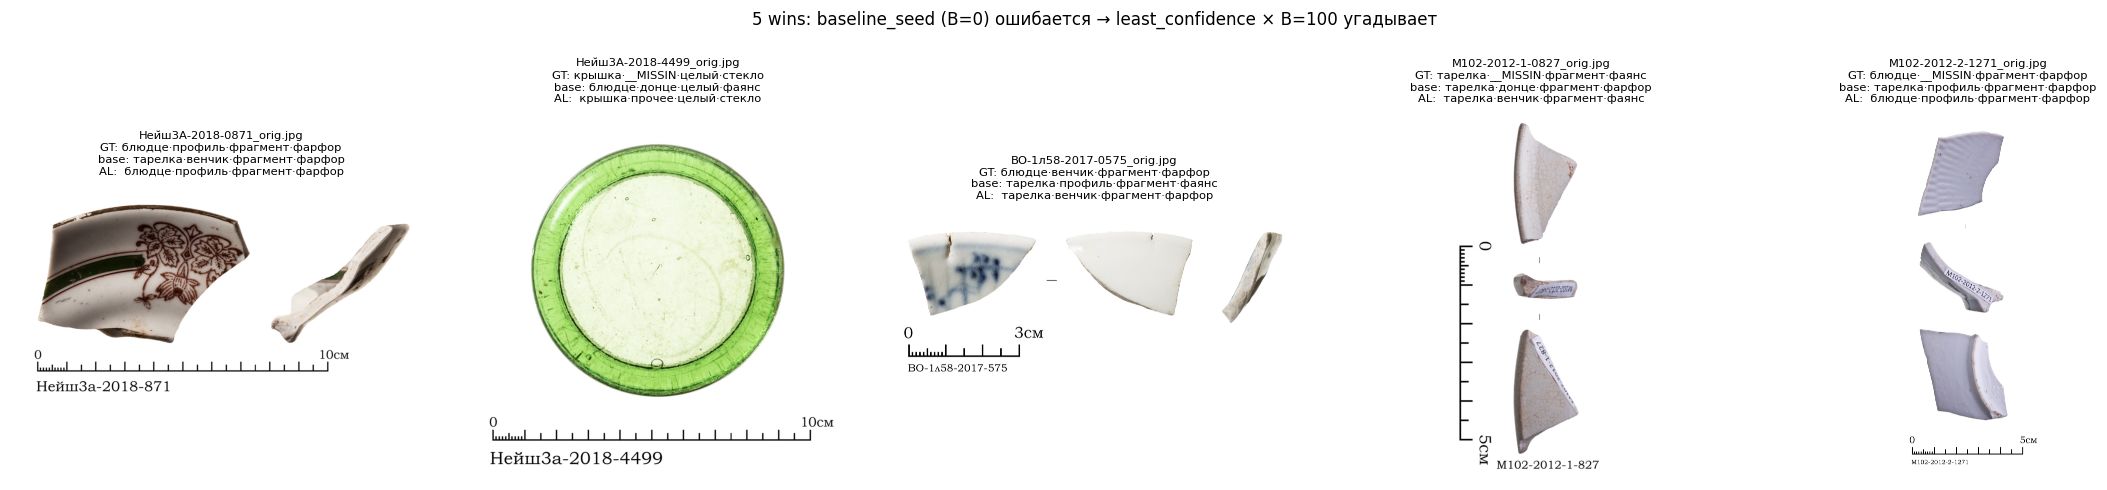

In [29]:
p = Path('artifacts/reports/data_centric/final_wins_grid.png')
if p.exists():
    display(Markdown('### 5 wins: baseline ошибся → AL угадал'))
    display(IPyImage(filename=str(p)))


### 5 still-hard: оба ошибаются

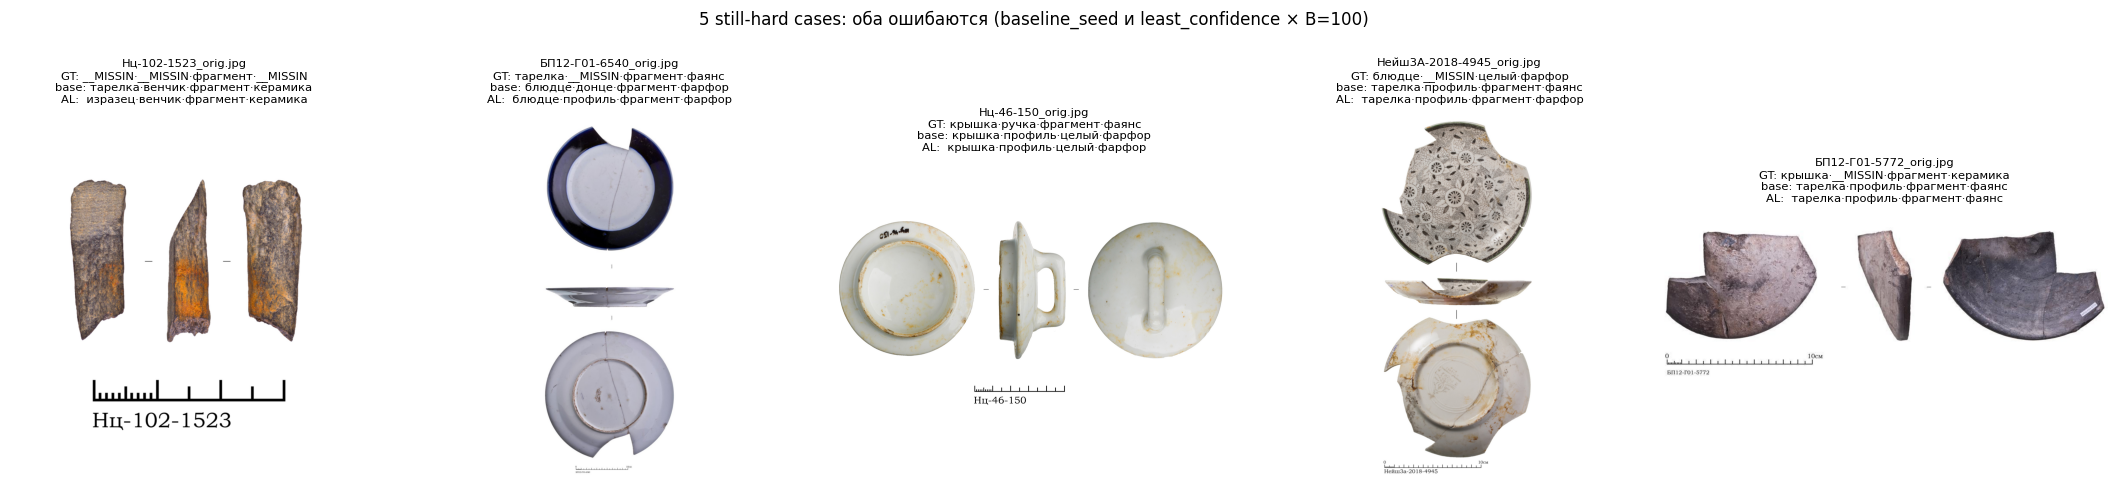

In [30]:
p = Path('artifacts/reports/data_centric/final_still_hard_grid.png')
if p.exists():
    display(Markdown('### 5 still-hard: оба ошибаются'))
    display(IPyImage(filename=str(p)))


In [31]:
wins = pd.read_csv('artifacts/reports/data_centric/final_wins_examples.csv')
display(Markdown('### final_wins_examples (top 5)'))
display(wins[['image_file','gt_material','baseline_pred_material','al_pred_material','wins_count','regressions_count']])
still = pd.read_csv('artifacts/reports/data_centric/final_still_hard_examples.csv')
display(Markdown('### final_still_hard_examples (top 5)'))
display(still[['image_file','gt_material','baseline_pred_material','al_pred_material','both_wrong_count']])


### final_wins_examples (top 5)

,image_file,gt_material,baseline_pred_material,al_pred_material,wins_count,regressions_count
0,data/raw/images/Нейш3А-2018-0871_orig.jpg,фарфор,фарфор,фарфор,2,0
1,data/raw/images/Нейш3А-2018-4499_orig.jpg,стекло,фаянс,стекло,2,0
2,data/raw/images/ВО-1л58-2017-0575_orig.jpg,фарфор,фаянс,фарфор,2,0
3,data/raw/images/М102-2012-1-0827_orig.jpg,фаянс,фарфор,фаянс,1,0
4,data/raw/images/М102-2012-2-1271_orig.jpg,фарфор,фарфор,фарфор,1,0


### final_still_hard_examples (top 5)

,image_file,gt_material,baseline_pred_material,al_pred_material,both_wrong_count
0,data/raw/images/Нц-102-1523_orig.jpg,__MISSING__,керамика,керамика,3
1,data/raw/images/БП12-Г01-6540_orig.jpg,фаянс,фарфор,фарфор,3
2,data/raw/images/Нц-46-150_orig.jpg,фаянс,фарфор,фарфор,3
3,data/raw/images/Нейш3А-2018-4945_orig.jpg,фарфор,фаянс,фарфор,3
4,data/raw/images/БП12-Г01-5772_orig.jpg,керамика,фаянс,фаянс,3


## 21. Финальный data-centric чек-лист

| Поле | Значение |
|---|---|
| Поля (primary/secondary) | `material` / `part` |
| Сплит | train_seed=350, val_gold=150, test_gold=209, pool_candidate=678 |
| Backbone | `convnext_tiny` (pretrained), 27.8M params |
| Image size | 384, `pad+resize` |
| Optimizer | AdamW (head_lr=3e-4, backbone_lr=3e-5, weight_decay=1e-4) |
| Scheduler | per-group cosine, min_lr=1e-6, freeze_backbone 2 epochs, 9 epochs total |
| Uncertainty signals | max_prob, entropy, margin (Spearman 0.99+) |
| Стратегии | random, least_confidence, coreset (+ hybrid query без retrain) |
| Бюджеты | B=50, B=100 |
| Лучший val_material@B=50 | **coreset = 0.788** (+0.085 vs baseline_seed) |
| Лучший test_material@B=100 | **least_confidence = 0.733** (+0.151 vs baseline_seed) |
| Финальный inference CSV | `artifacts/preds/inference_data_centric.csv` (1388 строк) |

**3 главных вывода о корпусе** (см. REPORT_DATA_CENTRIC.md раздел 21):
1. Корпус достаточно чистый по разметке — H3 не подтверждена auto-classification (10% < 30%); куратору нужна стандартизация словаря материала, а не массовая переразметка.
2. Главные источники ошибок — макет карточки (`multi_view`, `light_photo`) и редкие классы (`стекло` всего 19 видимых строк).
3. Pure uncertainty подвержен утечке через nuisance (4× больше close_up vs random). Production AL = uncertainty + nuisance-фильтр.
